In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import os
import re
import pandas as pd
from datetime import datetime

In [5]:
directory = r"O:\Tech_Photonics\Projects\Narrow Linewidth\MFB Chips\Chip 3 Feedback measurements\Linewidth enhancement data\20-12"


def n_digit_filename_convention(directory,n=3):
    # Regular expression to match the filenames
    pattern = r"no_(\d{1,"+n+r"})_(.+)\.txt"

    # Iterate over all files in the directory
    for filename in os.listdir(directory):
        match = re.match(pattern, filename)
        if match:
            number = int(match.group(1))  # Extract the number
            rest_of_name = match.group(2)

            # Create the new filename with three-digit formatting
            new_filename = f"no_{number:0{n}d}_{rest_of_name}.txt"

            # Rename the file
            os.rename(
                os.path.join(directory, filename),
                os.path.join(directory, new_filename)
            )

    print("Renaming completed!")

# n_digit_filename_convention(directory,n=3)

files = sorted(os.listdir(directory))

meas_no = int((len(files)-1)/6)

def path(file):
    return directory + '\\' + file

#Get paths of files in directory
paths_files = [path(file) for file in files]

In [6]:
def lin_to_dB(power):

    return 10*np.log10(power/1)

def ESA_peak_finder(file_path): #Returns peak frequency and power

    [freq,power] = np.loadtxt(file_path,skiprows=1)

    DC_cut_off_index = 50

    # plt.plot(freq[DC_cut_off_index:],power[DC_cut_off_index:])

    indices,peak_powers_dict = find_peaks(power[DC_cut_off_index:],height=[-70,0])

    indices += DC_cut_off_index

    if len(indices) == 0:

        return [0.0,-80.0]
    else:
        peak_powers =  peak_powers_dict['peak_heights']

        max_index = int(np.where(peak_powers == np.max(peak_powers))[0][0])

        if peak_powers[max_index] == power[indices[max_index]]:

            return [freq[indices[max_index]],peak_powers[max_index]] 
        
        else:
            print('ESA PEAK FAILURE!')
            return [0,0]
        


def OSA_peak_finder(file_path): #Returns peak wavelength and power

    data = np.loadtxt(file_path,skiprows=1,delimiter=',')

    wavelength = data[:,0]

    power = lin_to_dB(np.abs(data[:,1]))

    # plt.plot(wavelength,power)

    indices,peak_powers_dict = find_peaks(power,height=[-50,0])

    if len(indices) == 0:

        return [0.0,-80.0]
    else:
        peak_powers =  peak_powers_dict['peak_heights']


        max_index = int(np.where(peak_powers == np.max(peak_powers))[0][0])

        if peak_powers[max_index] == power[indices[max_index]]:

            return [wavelength[indices[max_index]],peak_powers[max_index]] 
        
        else:
            print('OSA PEAK FAILURE!')
            return [0,0] 

def powers_splitting_accounted_for(file_path,splitting_factor_follower = 40, splitting_factor_leader=1):
    
    data = np.loadtxt(file_path)

    data[0] *= splitting_factor_follower
    data[1] *= splitting_factor_leader

    return data



In [7]:
ESA_injected = np.array([[np.nan,np.nan]]*meas_no)
OSA_injected = np.array([[np.nan,np.nan]]*meas_no)
pow_follower_injected = np.array([np.nan]*meas_no)
pow_leader_injected = np.array([np.nan]*meas_no)


ESA_cold_cavity = np.array([[np.nan,np.nan]]*meas_no)
OSA_cold_cavity = np.array([[np.nan,np.nan]]*meas_no)
pow_follower_cold_cavity = np.array([np.nan]*meas_no)
pow_leader_cold_cavity = np.array([np.nan]*meas_no)


for i,file_path in enumerate(paths_files[1:]): #Skipping CSV file (MZI powermeter)

    file_name = files[1+i] #Not using the CSV file with the MZI powermeter

    no = int(file_name[3:6]) #The measurement number
    
    if 'ESA' in file_name:

        peak_data = ESA_peak_finder(file_path)
        # print(file_path, file_name, peak_data)

        if 'injected' in file_name:
            ESA_injected[no] = peak_data

        elif 'cold_cavity' in file_name:
            ESA_cold_cavity[no] = peak_data
        

    if 'OSA' in file_name:

        peak_OSA = OSA_peak_finder(file_path)

        if 'injected' in file_name:
            OSA_injected[no] = peak_OSA
            
        elif 'cold_cavity' in file_name:
            OSA_cold_cavity[no] = peak_OSA


    if 'powers' in file_name:

        [power_follow, power_lead] = powers_splitting_accounted_for(file_path, splitting_factor_follower=40, splitting_factor_leader=1)

        if 'injected' in file_name:
            pow_follower_injected[no] = power_follow
            pow_leader_injected[no] = power_lead
            
        elif 'cold_cavity' in file_name:
            pow_follower_cold_cavity[no] = power_follow
            pow_leader_cold_cavity[no] = power_lead


In [8]:
good_data_indices = []
for i in range(meas_no):

    if (ESA_injected[i][0] != 0.0) and (ESA_cold_cavity[i][0] != 0.0):
        good_data_indices.append(i)

good_data_indices = np.array(good_data_indices)
#Finding minima 

minima_indices = np.where (ESA_injected[good_data_indices][:,0] < np.percentile (ESA_injected[good_data_indices][:,0],15))[0]
print(good_data_indices[minima_indices], ', Fits with the data acquisition; It was only towards the end I got useful data (End is 194)')

[178 180 181 182 185] , Fits with the data acquisition; It was only towards the end I got useful data (End is 194)


AttributeError: 'Axes' object has no attribute 'x_label'

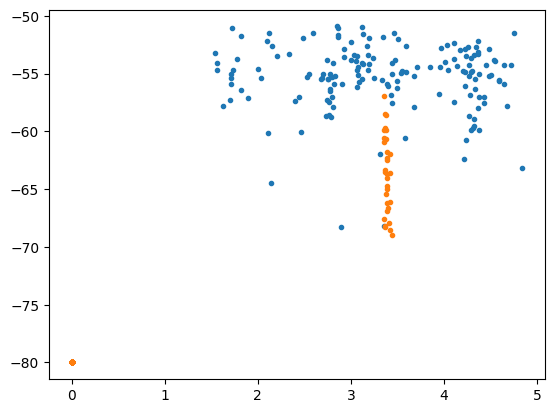

In [ ]:
fig,ax = plt.subplots()

ax.plot(ESA_cold_cavity[:,0]*1e-9,ESA_cold_cavity[:,1],'.',label='Cold cavity beatnote')
ax.plot(ESA_injected[:,0]*1e-9,ESA_injected[:,1],'.',label='Injected beatnote')
ax.xlabel
x_label('Beatnote [GHz]')
ax.ylabel('Peak amplitude [dBc]')
ax.legend(frameon=False)

# plt.label()
# plt.colorcoding

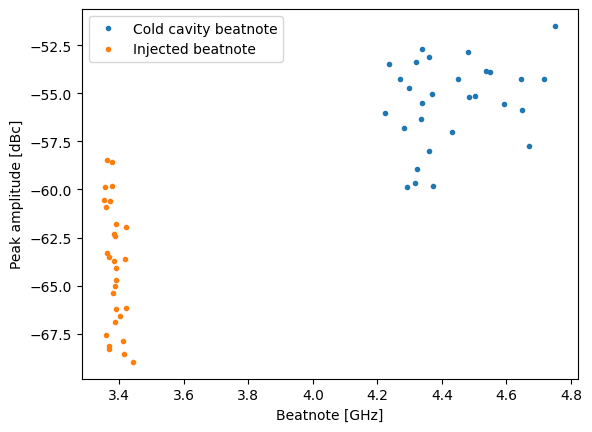

In [ ]:
plt.figure(4)

plt.plot(ESA_cold_cavity[good_data_indices][:,0]*1e-9,ESA_cold_cavity[good_data_indices][:,1],'.',label='Cold cavity beatnote')
plt.plot(ESA_injected[good_data_indices][:,0]*1e-9,ESA_injected[good_data_indices][:,1],'.',label='Injected beatnote')
plt.xlabel('Beatnote [GHz]')
plt.ylabel('Peak amplitude [dBc]')
plt.legend()

(3.35, 3.445)

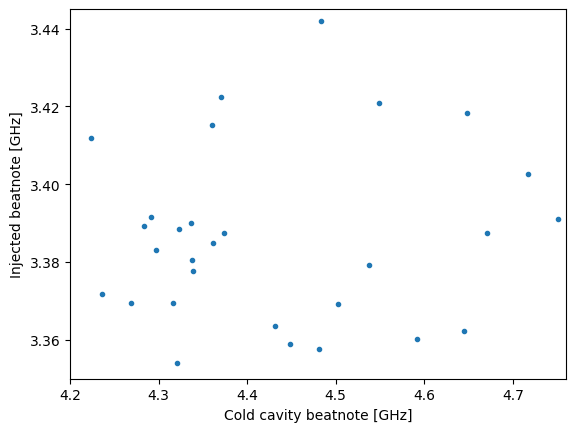

In [ ]:
plt.figure(3)

plt.plot(ESA_cold_cavity[:,0]*1e-9,ESA_injected[:,0]*1e-9,'.')
# plt.plot(ESA_cold_cavity[good_data_indices][:,0]*1e-9,ESA_injected[good_data_indices][:,0]*1e-9,'*')


plt.xlabel('Cold cavity beatnote [GHz]')
plt.ylabel('Injected beatnote [GHz]')
plt.xlim([4.2,4.76])
plt.ylim([3.35,3.445])

Text(0, 0.5, 'Injected beatnote [GHz]')

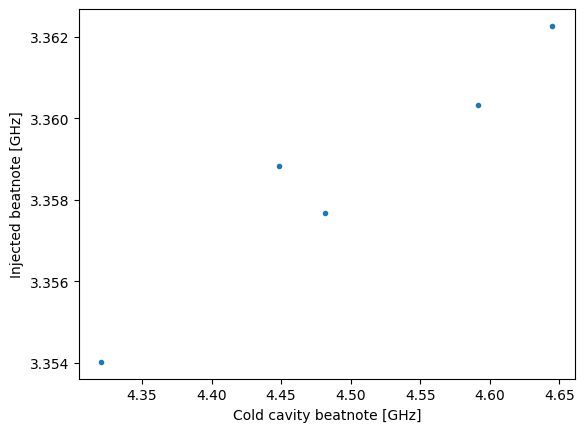

In [ ]:
plt.figure(5)

plt.plot(ESA_cold_cavity[good_data_indices[minima_indices]][:,0]*1e-9,ESA_injected[good_data_indices[minima_indices]][:,0]*1e-9,'.')
plt.xlabel('Cold cavity beatnote [GHz]')
plt.ylabel('Injected beatnote [GHz]')

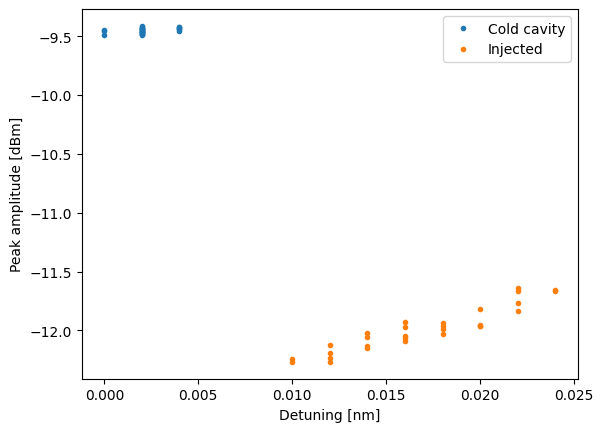

In [ ]:
carrier = 1549.698 #nm
factor =1e3

plt.plot(OSA_cold_cavity[good_data_indices][:,0]-carrier , OSA_cold_cavity[good_data_indices][:,1],'.',label='Cold cavity')
plt.plot(OSA_injected[good_data_indices][:,0]-carrier , OSA_injected[good_data_indices][:,1],'.',label='Injected')
plt.xlabel('Detuning [nm]')
plt.ylabel('Peak amplitude [dBm]')
plt.legend()

In [ ]:
carrier = 1549.698 #nm

1/(carrier+0.2) - 1/carrier

-8.326832052335791e-08

Limited by sampling interval (20 pm)! 
The resolution is 50 pm


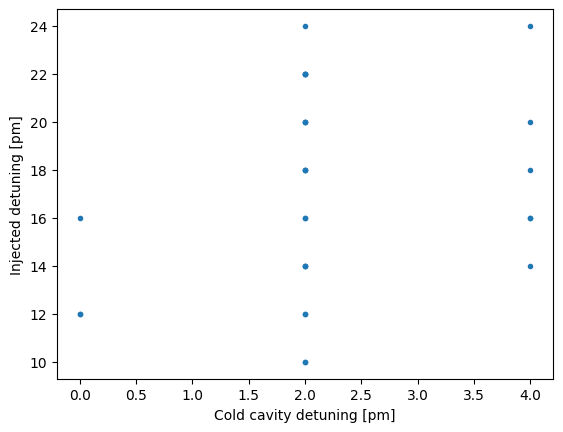

In [ ]:
plt.figure(3)

carrier = 1549.698 #nm
factor =1e3

plt.plot((OSA_cold_cavity[good_data_indices][:,0] -carrier)*factor ,(OSA_injected[good_data_indices][:,0]-carrier)*factor,'.')
plt.xlabel('Cold cavity detuning [pm]')
plt.ylabel('Injected detuning [pm]')
# plt.xlim([4,5])
# plt.ylim([3.3,3.5])
print('Limited by sampling interval (20 pm)! \nThe resolution is 50 pm')

Text(0, 0.5, 'Injected detuning [pm]')

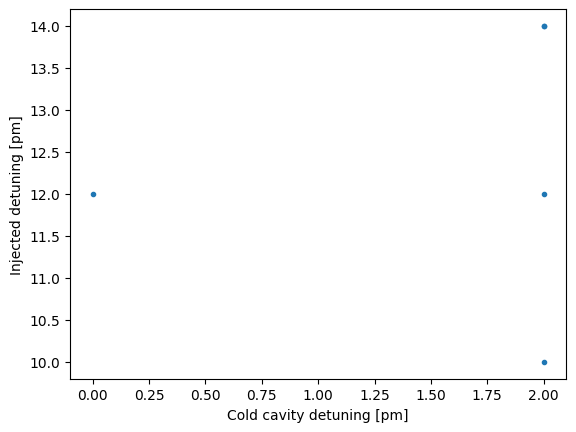

In [ ]:
plt.figure(3)

carrier = 1549.698 #nm
factor =1e3

plt.plot((OSA_cold_cavity[good_data_indices[minima_indices]][:,0] -carrier)*factor ,(OSA_injected[good_data_indices[minima_indices]][:,0]-carrier)*factor,'.')
plt.xlabel('Cold cavity detuning [pm]')
plt.ylabel('Injected detuning [pm]')
# plt.xlim([4,5])
# plt.ylim([3.3,3.5])


In [ ]:
OSA_cold_cavity[good_data_indices[minima_indices]][:,0]

array([1549.7  , 1549.7  , 1549.7  , 1549.698, 1549.7  ])

In [ ]:
np.savetxt(os.path.dirname(directory) + '\\' + '20_12_data.txt', (ESA_injected[:,0], ESA_cold_cavity[:,0], OSA_injected[:,0], OSA_cold_cavity[:,0], pow_follower_injected, pow_leader_injected, pow_follower_cold_cavity, pow_leader_cold_cavity) , header= 'ESA injected beatnote [freq, amplitude] \t ESA cold cavity beatnote [freq, amplitude] \t OSA injected [wavelength, amplitude] \t OSA cold cavity beatnote [wavelength, amplitude] \t Follower power injected \t Leader power injected \t Follower power cold cavity \t Leader power cold cavity')

In [ ]:
data_MZI = pd.read_csv(paths_files[0],engine='python',header=4,delimiter=';',skipfooter=8)

time_MZI_str = list(data_MZI[' Time of day (hh:mm:ss.fff)'])
power_MZI = np.array(list(data_MZI[' Power(W)']))

In [ ]:
time_MZI = np.empty((1,len(time_MZI_str)))[0]

for i,time in enumerate(time_MZI_str):
    tdelta = datetime.strptime(time,'%H:%M:%S.%f') - datetime.strptime(time_MZI_str[0],'%H:%M:%S.%f')

    time_MZI[i] = tdelta.total_seconds() #s


Text(0, 0.5, 'Power [$\\mu$W]')

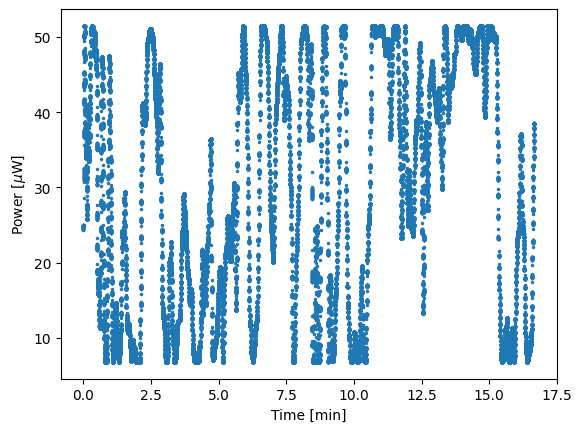

In [ ]:
plt.plot(time_MZI/60,power_MZI*1e6,'.', markersize = 3)

plt.xlabel('Time [min]')
plt.ylabel(r'Power [$\mu$W]')

In [ ]:


# # Assuming the data looks like this:
# # ESA_injected = [[freq1, amp1], [freq2, amp2], ...]
# # ESA_cold_cavity = [[freq1, amp1], [freq2, amp2], ...]
# # OSA_injected = [[wavelength1, amp1], [wavelength2, amp2], ...]
# # pow_follower_injected = [power1, power2, ...]
# # pow_leader_injected = [power1, power2, ...]

# # Convert all columns to strings where necessary
# ESA_injected_str = [f"[{x[0]}, {x[1]}]" for x in ESA_injected]
# ESA_cold_cavity_str = [f"[{x[0]}, {x[1]}]" for x in ESA_cold_cavity]
# OSA_injected_str = [f"[{x[0]}, {x[1]}]" for x in OSA_injected]
# OSA_cold_cavity_str = [f"[{x[0]}, {x[1]}]" for x in OSA_cold_cavity]

# # Combine all data into a single 2D array (list of lists)
# data = np.column_stack((
#     ESA_injected_str,
#     ESA_cold_cavity_str,
#     OSA_injected_str,
#     OSA_cold_cavity_str,
#     pow_follower_injected,
#     pow_leader_injected,
#     pow_follower_cold_cavity,
#     pow_leader_cold_cavity
# ))

# # Save to file
# output_file = os.path.dirname(directory) + '\\' + '20_12_data.txt'
# np.savetxt(output_file, data, fmt='%s', delimiter='\t',
#            header=('ESA injected beatnote [freq, amplitude] \t '
#                    'ESA cold cavity beatnote [freq, amplitude] \t '
#                    'OSA injected [wavelength, amplitude] \t '
#                    'OSA cold cavity beatnote [wavelength, amplitude] \t '
#                    'Follower power injected \t Leader power injected \t '
#                    'Follower power cold cavity \t Leader power cold cavity'))


In [ ]:
# loaded_data = np.loadtxt(output_file, dtype=str, delimiter='\t', skiprows=1)